# Lecture 02 (B01): Introduction to deep learning

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §1.1-1.4 (Foundations and function approximation), §1.5-1.9 (Optimization, depth, and regularization), §1.10-1.11 (Generalization, sequence models)  
**Notebook role:** core  
**Author:** Simon Scheidegger  


In [ ]:
# Run-mode switch (smoke = CPU-bounded for CI, teaching = laptop figures, production = full reproduction).
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


# Tutorial: Linear Regression, Classification, Unsupervised Learning, and Loss Functions

In this notebook we illustrate the core machine-learning concepts introduced
in the lecture:

1. **Linear Regression:** fit a linear model to synthetic data and measure
   prediction quality with MSE and MAE.
2. **Linear Classification:** train a logistic-regression classifier and
   visualise the decision boundary.
3. **Unsupervised Learning:** apply k-means clustering to discover natural
   groupings in unlabeled data.
4. **Loss Functions:** plot the standard losses for regression (squared error,
   absolute error) and classification (binary cross-entropy).

In [1]:
# ---------------------------------------------------------------
# Imports
# ---------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.datasets import make_classification, make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Fix the random seed so results are reproducible
np.random.seed(42)

---
## 1. Linear Regression

**Goal:** predict a continuous target $y \in \mathbb{R}$ from a single
feature $x$.

We generate synthetic data from the true model
$y = 3\,x + \varepsilon$, $\varepsilon \sim \mathcal{N}(0,1)$,
then fit a linear regression and evaluate it with standard metrics.

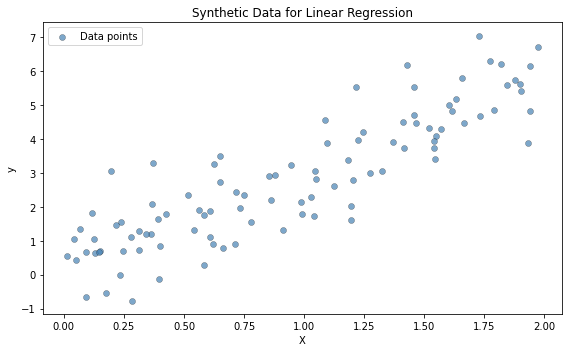

In [2]:
# ---------------------------------------------------------------
# Generate synthetic regression data
#   true relationship:  y = 3 * x + noise
# ---------------------------------------------------------------
n_samples = 100
X = 2 * np.random.rand(n_samples, 1)             # features in [0, 2]
y = 3 * X.squeeze() + np.random.randn(n_samples)  # slope=3, intercept=0

# Quick look at the raw data
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color="steelblue", alpha=0.7,
            edgecolors="k", linewidths=0.3, label="Data points")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic Data for Linear Regression")
plt.legend()
plt.tight_layout()
plt.show()

In [3]:
# ---------------------------------------------------------------
# Fit an ordinary least-squares linear regression
# ---------------------------------------------------------------
lin_reg = LinearRegression()
lin_reg.fit(X, y)

# Predicted values on the training set
y_pred = lin_reg.predict(X)

# Compute common regression loss metrics
mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)

print(f"Fitted model:  y = {lin_reg.coef_[0]:.3f} * x + {lin_reg.intercept_:.3f}")
print(f"Mean Squared Error  (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

Fitted model:  y = 2.770 * x + 0.215
Mean Squared Error  (MSE): 0.8066
Mean Absolute Error (MAE): 0.7010


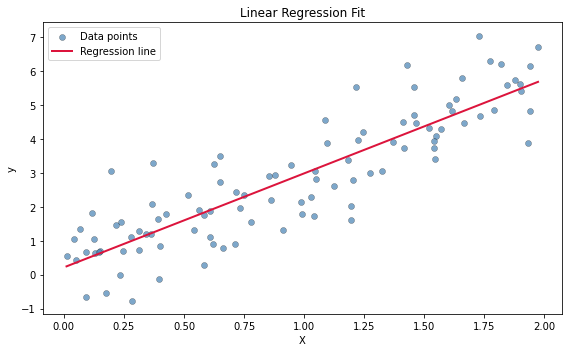

In [4]:
# ---------------------------------------------------------------
# Plot the fitted regression line on top of the data
# ---------------------------------------------------------------
X_sorted = np.sort(X, axis=0)  # sort for a clean line

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color="steelblue", alpha=0.7,
            edgecolors="k", linewidths=0.3, label="Data points")
plt.plot(X_sorted, lin_reg.predict(X_sorted),
         color="crimson", linewidth=2, label="Regression line")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression Fit")
plt.legend()
plt.tight_layout()
plt.show()

---
## 2. Linear Classification

**Goal:** assign each input $\mathbf{x}$ to one of $K$ classes.

We create a two-class dataset with two informative features, fit a
logistic-regression model, and visualise the resulting decision boundary.

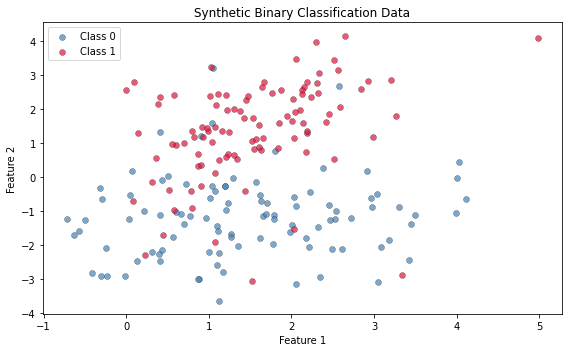

In [5]:
# ---------------------------------------------------------------
# Generate a synthetic binary-classification dataset
# ---------------------------------------------------------------
X_cls, y_cls = make_classification(
    n_samples=200, n_features=2,
    n_redundant=0, n_informative=2,
    n_clusters_per_class=1, flip_y=0.1,
    class_sep=1.5, random_state=42,
)

# Scatter plot coloured by class label
plt.figure(figsize=(8, 5))
plt.scatter(X_cls[y_cls == 0, 0], X_cls[y_cls == 0, 1],
            color="steelblue", edgecolors="k", linewidths=0.3,
            alpha=0.7, label="Class 0")
plt.scatter(X_cls[y_cls == 1, 0], X_cls[y_cls == 1, 1],
            color="crimson", edgecolors="k", linewidths=0.3,
            alpha=0.7, label="Class 1")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Synthetic Binary Classification Data")
plt.legend()
plt.tight_layout()
plt.show()

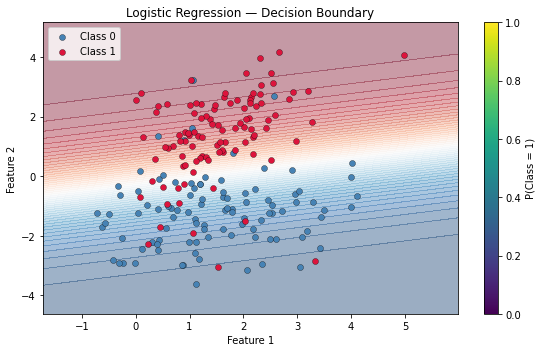

In [6]:
# ---------------------------------------------------------------
# Fit logistic regression and visualise the decision boundary
# ---------------------------------------------------------------
log_reg = LogisticRegression()
log_reg.fit(X_cls, y_cls)

# Build a dense mesh over the feature space
x_min, x_max = X_cls[:, 0].min() - 1, X_cls[:, 0].max() + 1
y_min, y_max = X_cls[:, 1].min() - 1, X_cls[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                      np.linspace(y_min, y_max, 300))

# Predicted P(class = 1) at every mesh point
Z = log_reg.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

# Probability shading  (blue = low P, red = high P)
# Colour convention matches the scatter:  Class 0 -> blue,  Class 1 -> red
plt.figure(figsize=(8, 5))
plt.contourf(xx, yy, Z, levels=50, alpha=0.4, cmap="RdBu_r")
plt.scatter(X_cls[y_cls == 0, 0], X_cls[y_cls == 0, 1],
            color="steelblue", edgecolors="k", linewidths=0.3, label="Class 0")
plt.scatter(X_cls[y_cls == 1, 0], X_cls[y_cls == 1, 1],
            color="crimson", edgecolors="k", linewidths=0.3, label="Class 1")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Logistic Regression \u2014 Decision Boundary")
plt.colorbar(label="P(Class = 1)")
plt.legend()
plt.tight_layout()
plt.show()

---
## 3. Unsupervised Learning K-Means Clustering

When **no labels** are available, we can still discover structure in the
data.  K-means partitions $n$ observations into $k$ clusters by
minimising the within-cluster sum of squared distances to the centroid.

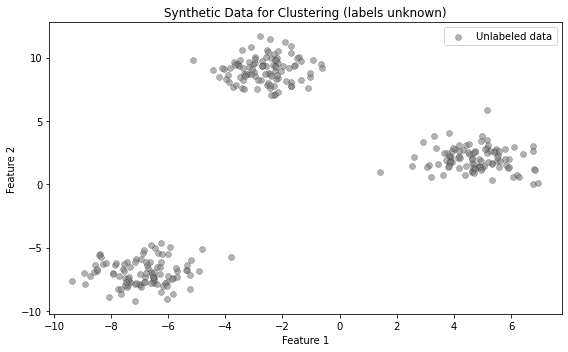

In [8]:
# ---------------------------------------------------------------
# Generate synthetic data with 3 natural clusters
# ---------------------------------------------------------------
X_blobs, _ = make_blobs(n_samples=300, centers=3,
                         cluster_std=1.0, random_state=42)

# Before clustering: all points look the same
plt.figure(figsize=(8, 5))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1],
            color="gray", alpha=0.6, edgecolors="k", linewidths=0.3,
            label="Unlabeled data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Synthetic Data for Clustering (labels unknown)")
plt.legend()
plt.tight_layout()
plt.show()

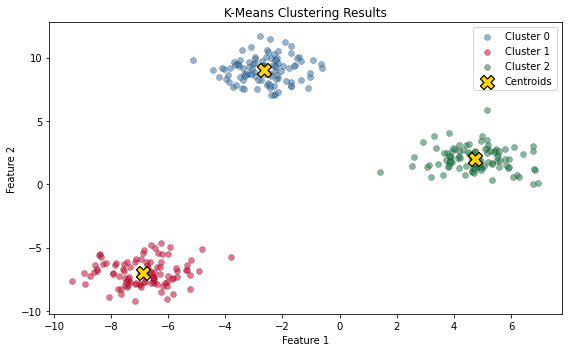

In [9]:
# ---------------------------------------------------------------
# Fit k-means with k = 3 and visualise the discovered clusters
# ---------------------------------------------------------------
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
labels = kmeans.fit_predict(X_blobs)

# Plot each cluster in a different colour
plt.figure(figsize=(8, 5))
colors = ["steelblue", "crimson", "seagreen"]
for k in range(3):
    mask = labels == k
    plt.scatter(X_blobs[mask, 0], X_blobs[mask, 1],
                color=colors[k], alpha=0.6,
                edgecolors="k", linewidths=0.3,
                label=f"Cluster {k}")

# Mark the centroids
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, c="gold", marker="X",
            edgecolors="k", linewidths=1.2,
            label="Centroids")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering Results")
plt.legend()
plt.tight_layout()
plt.show()

---
## 4. Loss Functions

The **loss function** $J(\boldsymbol{\theta})$ measures how far
predictions $\hat{y}$ are from the true targets $y$.
Every supervised-learning algorithm follows the same recipe:

1. Choose a model $\hat{y} = h(\mathbf{x};\boldsymbol{\theta})$
2. Define a loss $J(\boldsymbol{\theta})$
3. Optimise $\boldsymbol{\theta}^{*} = \arg\min J(\boldsymbol{\theta})$

### Regression losses

| Loss | Per-sample formula |
|---|---|
| Squared error (MSE) | $(y - \hat{y})^{2}$ |
| Absolute error (MAE) | $\lvert y - \hat{y}\rvert$ |

### Classification loss \u2014 Binary Cross-Entropy

$$
J = -\Bigl[y\,\log\hat{y} \;+\; (1-y)\,\log(1-\hat{y})\Bigr],
\qquad y\in\{0,1\},\;\hat{y}\in(0,1)
$$

This is the standard loss used in logistic regression and neural-network
classifiers (see lecture slides).

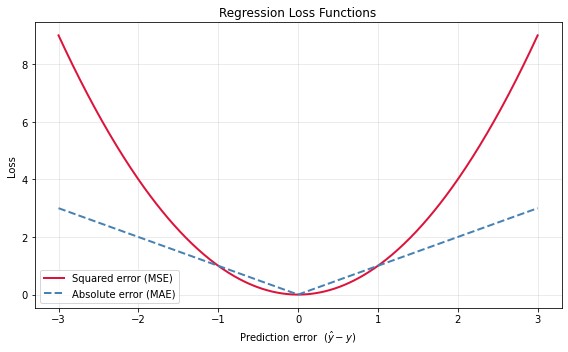

In [10]:
# ---------------------------------------------------------------
# Regression loss functions as a function of prediction error
# ---------------------------------------------------------------
errors = np.linspace(-3, 3, 400)

squared_error = errors ** 2       # quadratic penalty
absolute_error = np.abs(errors)   # linear penalty

plt.figure(figsize=(8, 5))
plt.plot(errors, squared_error,
         color="crimson", linewidth=2, label="Squared error (MSE)")
plt.plot(errors, absolute_error,
         color="steelblue", linewidth=2, linestyle="--",
         label="Absolute error (MAE)")
plt.xlabel(r"Prediction error  $(\hat{y} - y)$")
plt.ylabel("Loss")
plt.title("Regression Loss Functions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

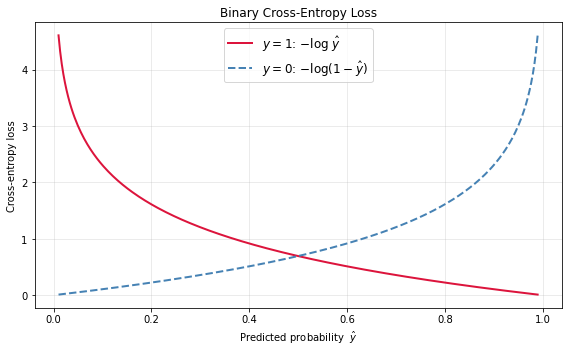

In [11]:
# ---------------------------------------------------------------
# Binary cross-entropy loss as a function of predicted probability
#
#   CE(y, y_hat) = -[ y * log(y_hat) + (1 - y) * log(1 - y_hat) ]
#
# We plot both cases:  y = 1  and  y = 0.
# ---------------------------------------------------------------
y_hat = np.linspace(0.01, 0.99, 300)  # predicted probabilities in (0, 1)

ce_loss_y1 = -np.log(y_hat)       # loss when the true label is 1
ce_loss_y0 = -np.log(1 - y_hat)   # loss when the true label is 0

plt.figure(figsize=(8, 5))
plt.plot(y_hat, ce_loss_y1,
         color="crimson", linewidth=2,
         label=r"$y=1$: $-\log\,\hat{y}$")
plt.plot(y_hat, ce_loss_y0,
         color="steelblue", linewidth=2, linestyle="--",
         label=r"$y=0$: $-\log(1-\hat{y})$")
plt.xlabel(r"Predicted probability  $\hat{y}$")
plt.ylabel("Cross-entropy loss")
plt.title("Binary Cross-Entropy Loss")
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Conclusion

In this notebook we:

- **Linear Regression:** fitted a line to synthetic data and measured
  prediction quality with MSE and MAE.
- **Classification:** trained a logistic-regression model and visualised
  its decision boundary.
- **Clustering:** applied k-means to recover natural groups in unlabeled
  data.
- **Loss Functions:** plotted the squared-error, absolute-error, and
  binary cross-entropy losses.

These building blocks \u2014 models, losses, and optimisation \u2014 reappear
throughout the course as we move to deep neural networks.